In [1]:
import time
import h5py
import shutil
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from chemrixs.average import Average
from chemrixs.smalldata import SmallData
from chemrixs.process import Reduced
from chemrixs.utils import *
from pathlib import Path
%matplotlib widget 

In [ ]:
os.makedirs('proc', exist_ok=True)
os.makedirs('avg', exist_ok=True)
os.makedirs('figs', exist_ok=True)

proc/Run
[112. 192. 202. 202. 202. 208. 209. 200. 202. 196. 206. 199. 197. 207.
 205. 205. 208. 197. 201. 203. 197. 195. 200. 206. 205. 189. 200. 200.
 189. 195. 202. 191. 193. 204. 193. 194. 196. 194. 189.]
[344. 390. 404. 407. 415. 416. 402. 408. 403. 396. 402. 401. 412. 409.
 407. 406. 413. 392. 402. 403. 400. 404. 395. 401. 406. 377. 401. 398.
 389. 391. 405. 384. 382. 400. 385. 390. 390. 390. 383.]
[507. 587. 616. 614. 610. 626. 607. 610. 604. 601. 605. 599. 625. 616.
 608. 605. 614. 589. 605. 604. 600. 606. 594. 600. 607. 574. 596. 593.
 583. 588. 616. 579. 571. 595. 574. 589. 579. 585. 584.]
[678. 792. 813. 819. 814. 836. 806. 809. 807. 804. 815. 808. 820. 820.
 808. 810. 813. 791. 806. 808. 803. 805. 788. 800. 807. 769. 794. 799.
 771. 786. 812. 774. 762. 796. 769. 785. 774. 772. 777.]
[-8.93617000e-02  7.35308511e+02]
[-8.93617000e-02  7.35308511e+02]


/sdf/data/lcls/ds/rix/rix101231825/results/Zhaoyuan/DataAcceleratorChemRIXS/src/chemrixs/utils.py:455: RuntimeWarning: Mean of empty slice
  data_trans[ii,i] = np.nanmean(data[ii, mask])
/sdf/data/lcls/ds/rix/rix101231825/results/Zhaoyuan/DataAcceleratorChemRIXS/src/chemrixs/utils.py:456: RuntimeWarning: invalid value encountered in scalar divide
  std_trans[ii,i] = np.sqrt(np.sum(std[ii, mask]**2)) / N


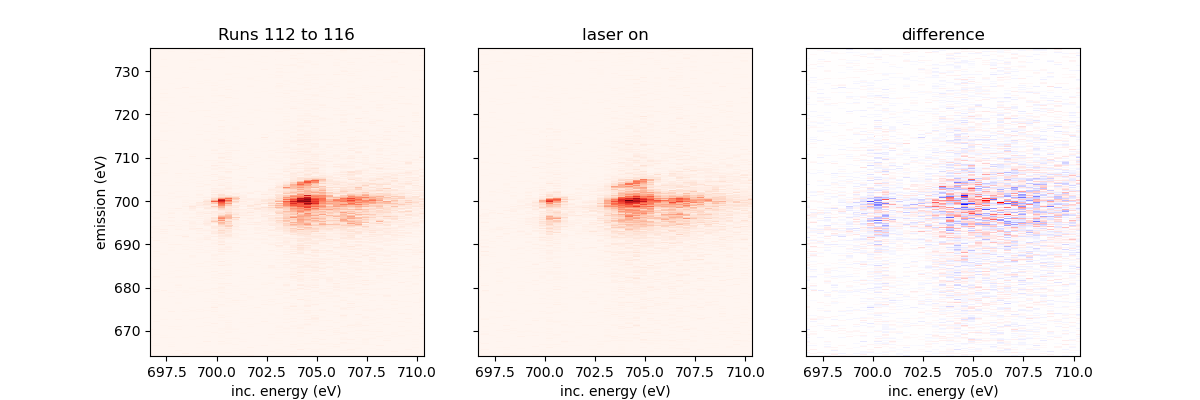

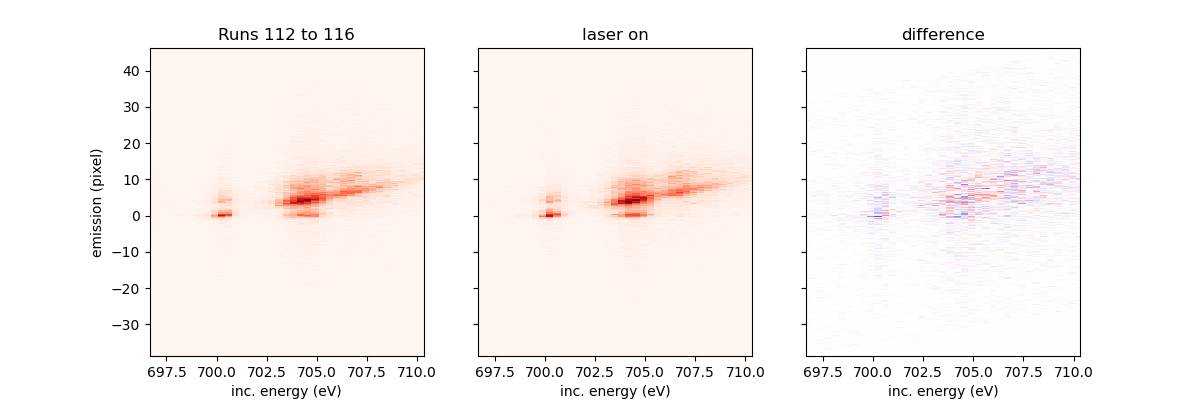

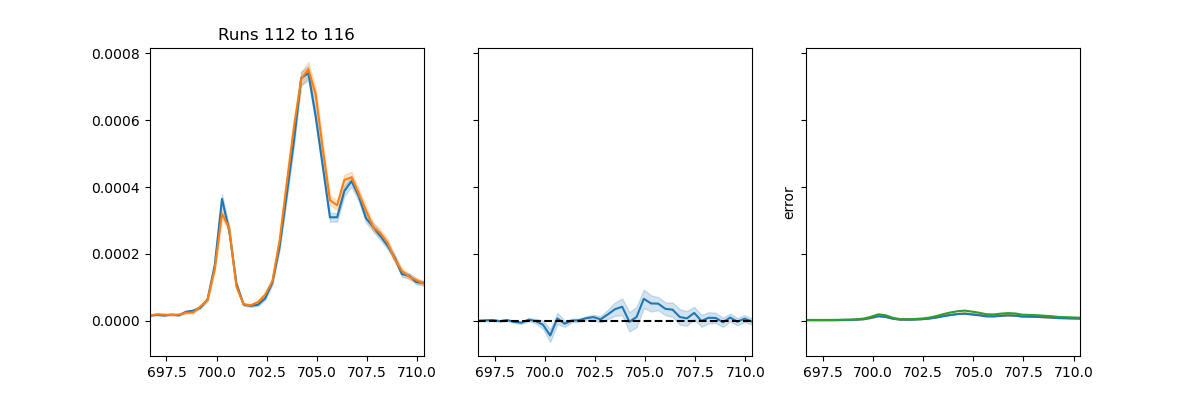

In [ ]:
base_folder =  '/sdf/data/lcls/ds/rix/'
proc_folder = './proc/'


bgrun = 86 #shift2
# bgrun = 86 #shift3
# bgrun = 191 #shift4

# runs = [45,46]
runs=[112,114,115,116,117,118,119,120,121,122,123,127,129,]
# runs = [138,139,140,141,145]
# runs = [112,114,115,116,117,118,119,120,121,122,123,127,129,138,139,140,141,145]
# runs = [112,114,115,116]
# runs = [178,179,180,181,182,183,184,185,186,188]
# runs = [226]
exp = 'rix101231825'


fyaml = '../roi_input.yml'

bgname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{bgrun:04d}.h5'
bgyaml = '../BGroi_input.yml'

avg = Average(runs, proc_path = 'proc/Run', avg = 'mean', output_path = f'avg/{runs[0]}_to_{runs[-1]}.h5',
             raw_path = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run' , bgpath = bgname, fyaml=fyaml, bgyaml=bgyaml, 
             save= True,norm = True)

avg.plot_svls2D(figsize=(12,4),savefig=True)
avg.plot_svls2D_ET(figsize=(12,4),savefig=False)
avg.plot_svls1D(figsize=(12,4))

In [24]:
base_folder = '/sdf/data/lcls/ds/rix/'
exp = 'rix101231825'
bgname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run0086.h5'
fyaml = '../roi_input.yml'
bgyaml = '../BGroi_input.yml'
RUN = 140
variant_tags = ['th60_tha455','th60_tha440','th70_tha455','th70_tha440',
                'th80_tha455','th80_tha440','th100_tha455','th100_tha440']
# variant_tags = ['th60_tha455','th60_tha440','th70_tha455','th70_tha440', 'th80_tha455']

os.makedirs('proc', exist_ok=True)
os.makedirs('avg', exist_ok=True)

avg_results = {}
for tag in variant_tags:
    print(f'\n===== {tag} =====')
    variant_h5  = f'{base_folder}/{exp}/hdf5/smalldata/run{RUN}_{tag}/{exp}_Run{RUN:04d}.h5'
    variant_dir = f'proc_variants/{tag}'
    os.makedirs(variant_dir, exist_ok=True)
    proc_file   = f'{variant_dir}/Run{RUN:04d}.h5'

    # reduce if not already done
    if not os.path.isfile(proc_file):
        Reduced(variant_h5, bgname, fyaml, bgyaml,
                save=True, scantype='mono_fly', norm=True)
        shutil.move(f'./proc/Run{RUN:04d}.h5', proc_file)
        print(f'  saved -> {proc_file}')

    # now Average can find it: proc_path + '0140.h5' = variant_dir/Run0140.h5
    avg = Average([RUN], proc_path=f'{variant_dir}/Run', avg='mean',
                  output_path=f'avg/{RUN}_{tag}.h5',
                  raw_path=f'{base_folder}/{exp}/hdf5/smalldata/run{RUN}_{tag}/{exp}_Run',
                  bgpath=bgname, fyaml=fyaml, bgyaml=bgyaml,
                  save=True, norm=True, scantype='mono_fly')
    avg_results[tag] = avg


===== th60_tha455 =====
proc_variants/th60_tha455/Run
[159. 207. 204. 206. 218. 207. 197. 207. 208. 198. 200. 198. 204. 203.
 203. 202. 202. 198. 198. 199. 201. 200. 211. 196. 201. 191. 201. 195.
 189. 205. 199. 196. 192. 197. 190. 196. 196. 192. 204.]

===== th60_tha440 =====
proc_variants/th60_tha440/Run
[158. 207. 204. 206. 218. 207. 197. 207. 208. 198. 200. 198. 204. 203.
 203. 202. 202. 198. 198. 199. 201. 200. 211. 196. 201. 191. 201. 195.
 189. 205. 199. 196. 192. 197. 190. 196. 196. 192. 204.]

===== th70_tha455 =====
proc_variants/th70_tha455/Run
[158. 207. 204. 206. 218. 207. 197. 207. 208. 198. 200. 198. 204. 203.
 203. 202. 202. 198. 198. 199. 201. 200. 211. 196. 201. 191. 201. 195.
 189. 205. 199. 196. 192. 197. 190. 196. 196. 192. 204.]

===== th70_tha440 =====
proc_variants/th70_tha440/Run
[157. 207. 204. 206. 218. 207. 197. 207. 208. 198. 200. 198. 204. 203.
 203. 202. 202. 198. 198. 199. 201. 200. 211. 196. 201. 191. 201. 195.
 189. 205. 199. 196. 192. 197. 190. 196. 

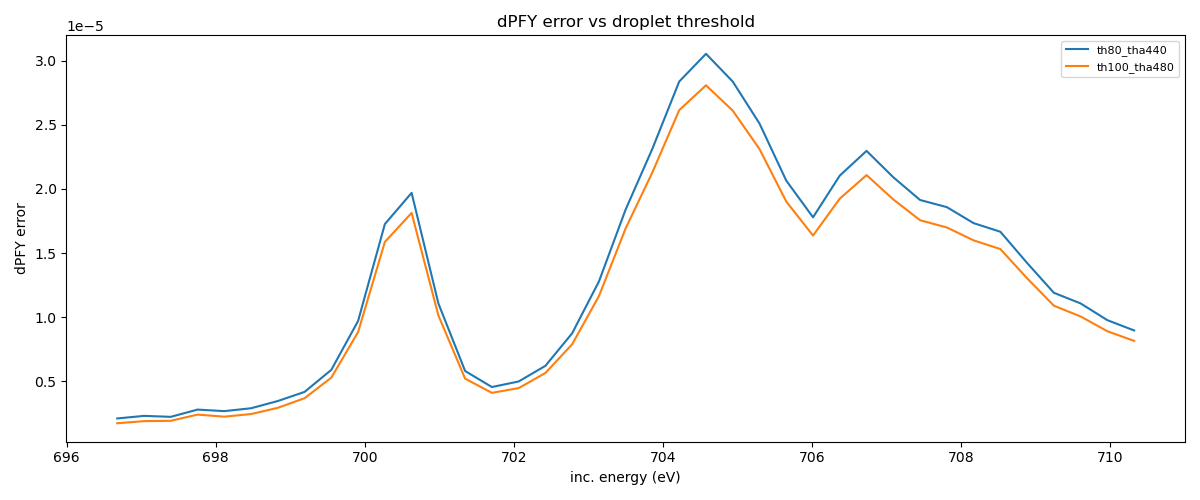

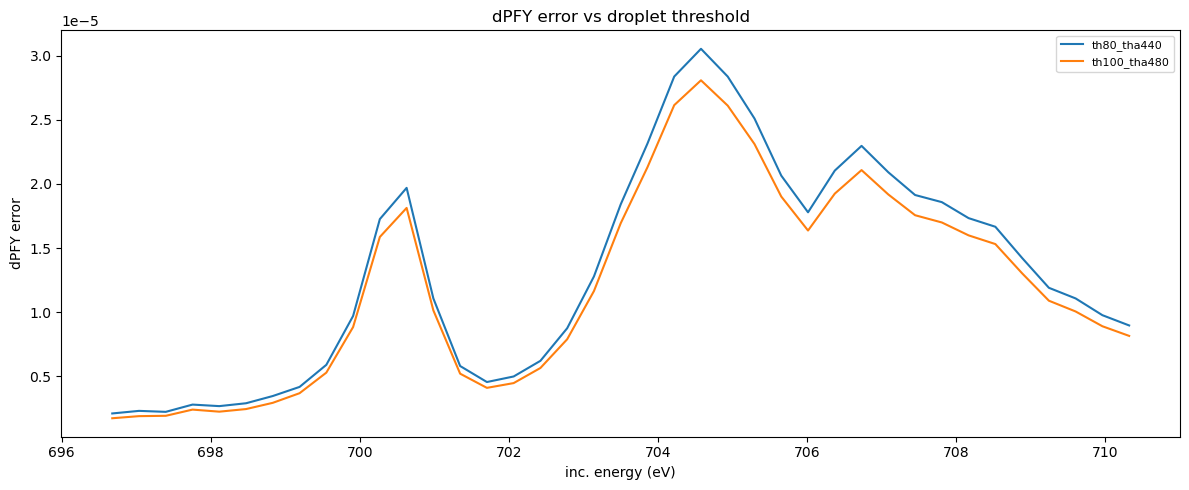

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def overlay_dPFYerr(avg_results, figsize=(12, 5)):
    """Overlay the dPFY error trace (sqrt(on_std^2 + off_std^2)) for each variant."""
    fig, ax = plt.subplots(figsize=figsize)

    for tag, avg in avg_results.items():
        a = avg.average
        # make sure PFYs exist (get_PFYs populates PFY_*_mean / PFY_*_std)
        if 'PFY_on_std' not in a:
            avg.get_PFYs()
            a = avg.average

        scanvar = a['scanvar_off']
        dPFYerr = np.sqrt(a['PFY_on_std']**2 + a['PFY_off_std']**2)
        ax.plot(scanvar, dPFYerr, label=tag)

    ax.set_xlabel('inc. energy (eV)')
    ax.set_ylabel('dPFY error')
    ax.set_title('dPFY error vs droplet threshold')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
    return fig

overlay_dPFYerr(avg_results)

[-8.93617000e-02  7.35308511e+02]
[-8.93617000e-02  7.35308511e+02]


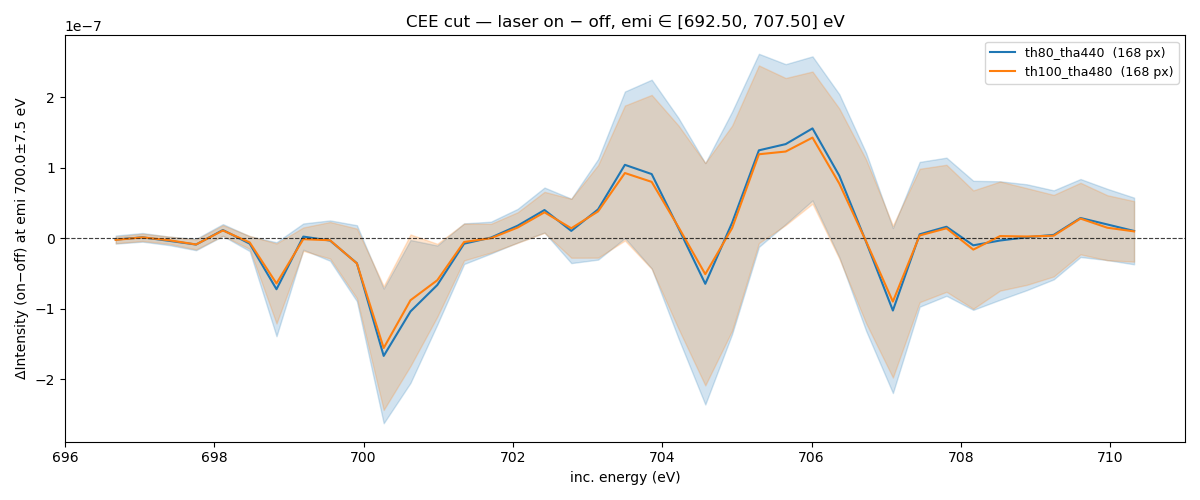

In [35]:
def plot_CEE(avg_results, emi_center, emi_width, use='off',
             plot_err=True, figsize=(12, 5)):
    """
    Constant Emission Energy cut overlay across variants.

    Sums (averages) the 2D RIXS map over [emi_center - emi_width/2,
    emi_center + emi_width/2] in emission energy, plots vs incident energy.

    Parameters
    ----------
    avg_results : dict {tag: Average}
    emi_center  : float, center of emission window (eV)
    emi_width   : float, full width of window (eV)
    use         : 'off', 'on', or 'diff' (laser-on minus laser-off)
    plot_err    : if True, shade ±std (propagated across summed pixels)
    """
    if use not in ('off', 'on', 'diff'):
        raise ValueError(f"use must be 'off', 'on', or 'diff', got {use!r}")

    fig, ax = plt.subplots(figsize=figsize)

    emi_lo = emi_center - emi_width / 2
    emi_hi = emi_center + emi_width / 2

    for tag, avg in avg_results.items():
        a = avg.average
        emi = avg.get_emi()
        emi_mask = (emi >= emi_lo) & (emi <= emi_hi)
        n_emi = emi_mask.sum()
        if n_emi == 0:
            print(f'  {tag}: NO pixels in emission window [{emi_lo}, {emi_hi}]')
            continue

        if use == 'diff':
            inc = np.asarray(a['scanvar_off'])
            Z_off = np.asarray(a['axis_svls_off_mean'])
            Z_on  = np.asarray(a['axis_svls_on_mean'])

            cee_off = np.nanmean(Z_off[:, emi_mask], axis=1)
            cee_on  = np.nanmean(Z_on[:,  emi_mask], axis=1)
            cee = cee_on - cee_off

            line, = ax.plot(inc, cee, label=f'{tag}  ({n_emi} px)')
            ax.axhline(0, color='k', ls='--', lw=0.8, alpha=0.5)

            # propagated error for the difference
            if (plot_err and 'axis_svls_off_std' in a
                    and 'axis_svls_on_std' in a):
                Zstd_off = np.asarray(a['axis_svls_off_std'])
                Zstd_on  = np.asarray(a['axis_svls_on_std'])
                err_off = np.sqrt(np.nansum(Zstd_off[:, emi_mask]**2, axis=1)) / n_emi
                err_on  = np.sqrt(np.nansum(Zstd_on[:,  emi_mask]**2, axis=1)) / n_emi
                cee_err = np.sqrt(err_off**2 + err_on**2)
                ax.fill_between(inc, cee - cee_err, cee + cee_err,
                                color=line.get_color(), alpha=0.2)
        else:
            inc = np.asarray(a[f'scanvar_{use}'])
            Z   = np.asarray(a[f'axis_svls_{use}_mean'])
            cee = np.nanmean(Z[:, emi_mask], axis=1)

            line, = ax.plot(inc, cee, label=f'{tag}  ({n_emi} px)')

            if plot_err and f'axis_svls_{use}_std' in a:
                Zstd = np.asarray(a[f'axis_svls_{use}_std'])
                cee_err = np.sqrt(np.nansum(Zstd[:, emi_mask]**2, axis=1)) / n_emi
                ax.fill_between(inc, cee - cee_err, cee + cee_err,
                                color=line.get_color(), alpha=0.2)

    ax.set_xlabel('inc. energy (eV)')
    if use == 'diff':
        ax.set_ylabel(f'ΔIntensity (on−off) at emi {emi_center}±{emi_width/2} eV')
        title_use = 'laser on − off'
    else:
        ax.set_ylabel(f'Intensity at emi {emi_center}±{emi_width/2} eV')
        title_use = f'laser {use}'
    ax.set_title(f'CEE cut — {title_use}, emi ∈ [{emi_lo:.2f}, {emi_hi:.2f}] eV')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


# Usage:
# plot_CEE(avg_results, emi_center=703.0, emi_width=1.0, use='off')
# plot_CEE(avg_results, emi_center=703.0, emi_width=1.0, use='on')
plot_CEE(avg_results, emi_center=700.0, emi_width=15.0, use='diff')

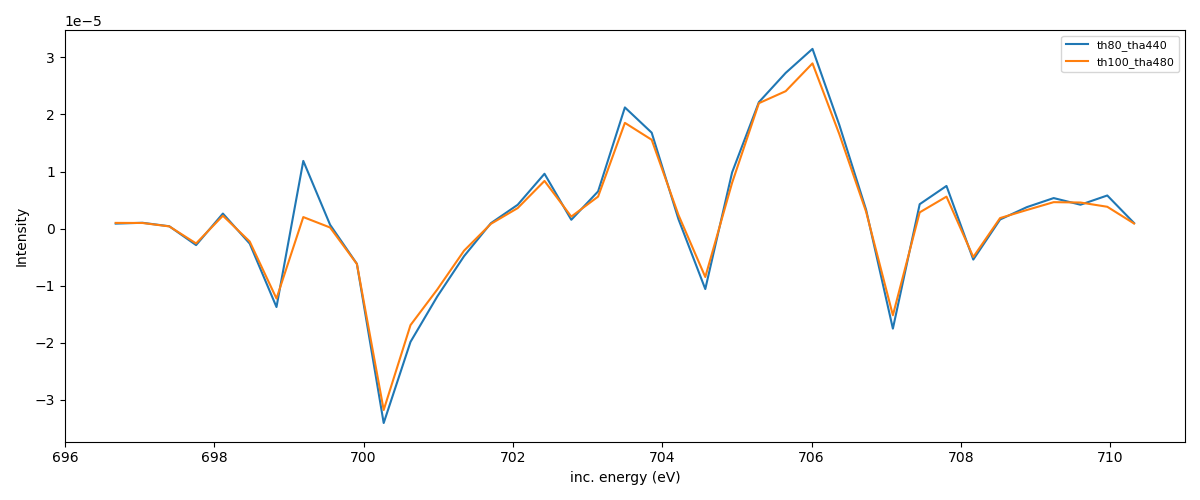

In [39]:
fig, ax = plt.subplots(figsize=(12, 5))
for tag, avg in avg_results.items():
        a = avg.average
    # make sure PFYs exist (get_PFYs populates PFY_*_mean / PFY_*_std)
        if 'PFY_on_std' not in a:
            avg.get_PFYs()
            a = avg.average

        scanvar = a['scanvar_off']
        dPFYerr = np.sqrt(a['PFY_on_std']**2 + a['PFY_off_std']**2)
        ax.plot(scanvar, a['PFY_on_mean'] - a['PFY_off_mean'], label=tag)
        # ax.plot(scanvar, dPFYerr, label=f'{tag} error', ls='--')

ax.set_xlabel('inc. energy (eV)')
ax.set_ylabel('Intensity')
# ax.set_title('dPFY error vs droplet threshold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

for plotting avg of a few runs using different noise/adu threshold

In [2]:
base_folder = '/sdf/data/lcls/ds/rix/'
exp = 'rix101231825'
bgname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run0086.h5'
fyaml = '../roi_input.yml'
bgyaml = '../BGroi_input.yml'

runs = [112,114,115,116,117,118,119,120,121,122,123,127,129]
variant_tags = ['th80_tha440', 'th100_tha480']

os.makedirs('proc', exist_ok=True)
os.makedirs('avg', exist_ok=True)

avg_results = {}
for tag in variant_tags:
    print(f'\n===== variant {tag} =====')
    variant_dir = f'proc_variants/{tag}'
    os.makedirs(variant_dir, exist_ok=True)

    # --- reduce every run for this variant ---
    for RUN in runs:
        variant_h5 = f'{base_folder}/{exp}/hdf5/smalldata/run{RUN}_{tag}/{exp}_Run{RUN:04d}.h5'
        proc_file  = f'{variant_dir}/Run{RUN:04d}.h5'

        if not os.path.isfile(proc_file):
            if not os.path.isfile(variant_h5):
                print(f'  !! MISSING raw file, skipping: {variant_h5}')
                continue
            print(f'  reducing run {RUN} ...')
            Reduced(variant_h5, bgname, fyaml, bgyaml,
                    save=True, scantype='mono_fly', norm=True)
            # Reduced always writes ./proc/RunXXXX.h5 — move it into the variant folder
            shutil.move(f'./proc/Run{RUN:04d}.h5', proc_file)
            print(f'    saved -> {proc_file}')
        else:
            print(f'  run {RUN} already reduced -> {proc_file}')

    # --- average all runs for this variant ---
    # Average reads proc_path + f'{run:04d}.h5' for each run in `runs`,
    # so all proc files must sit in variant_dir named RunXXXX.h5  (they do)
    avg = Average(runs, proc_path=f'{variant_dir}/Run', avg='mean',
                  output_path=f'avg/{runs[0]}_to_{runs[-1]}_{tag}.h5',
                  raw_path=f'{base_folder}/{exp}/hdf5/smalldata/REPLACED_BELOW',
                  bgpath=bgname, fyaml=fyaml, bgyaml=bgyaml,
                  save=True, norm=True, scantype='mono_fly')
    avg_results[tag] = avg
    print(f'  averaged {len(runs)} runs for {tag}')


===== variant th80_tha440 =====
  reducing run 112 ...
112
setting up properties
dataset prop <functools.cached_property object at 0x7fc08051cbd0>
dataset prop <functools.cached_property object at 0x7fc0888ecf90>
dataset prop <functools.cached_property object at 0x7fc0301d7fd0>
dataset prop <functools.cached_property object at 0x7fc02e1dbf50>
dataset prop <functools.cached_property object at 0x7fc02e1e6bd0>
dataset prop <functools.cached_property object at 0x7fc02e14fe90>
dataset prop <functools.cached_property object at 0x7fc02ec29710>
dataset prop <functools.cached_property object at 0x7fc02f97b5d0>
86
setting up properties
dataset prop <functools.cached_property object at 0x7fc02f933510>
dataset prop <functools.cached_property object at 0x7fc02f978c50>
dataset prop <functools.cached_property object at 0x7fc02e203dd0>
dataset prop <functools.cached_property object at 0x7fc02e1e8250>
dataset prop <functools.cached_property object at 0x7fc02e203050>
dataset prop <functools.cached_prop

In [6]:
avg_results.keys()

dict_keys(['th80_tha440', 'th100_tha480'])

[-8.93617000e-02  7.35308511e+02]
th80_tha440:  mean=+2.9596e-07   std=2.0596e-07   (115 pixels, 5 inc bins × 23 emi pixels)
[-8.93617000e-02  7.35308511e+02]
th100_tha480:  mean=+2.6199e-07   std=1.8829e-07   (115 pixels, 5 inc bins × 23 emi pixels)


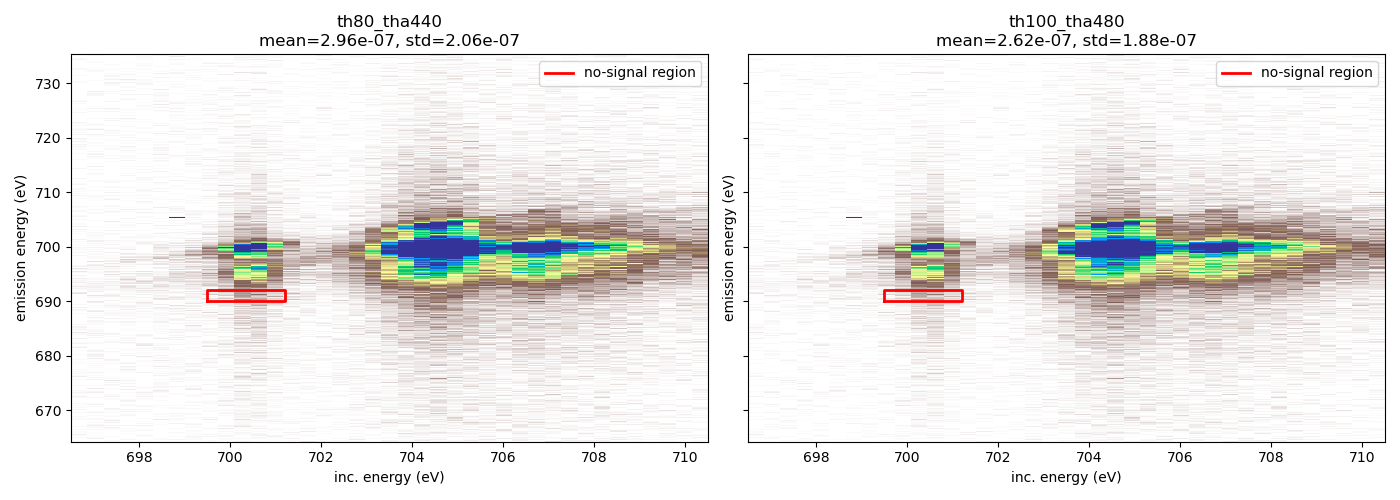

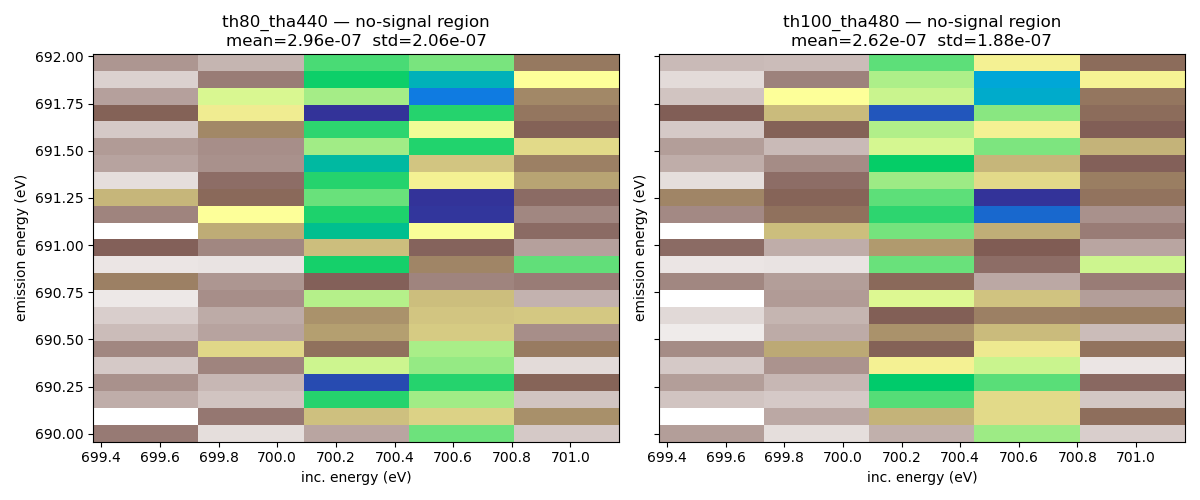

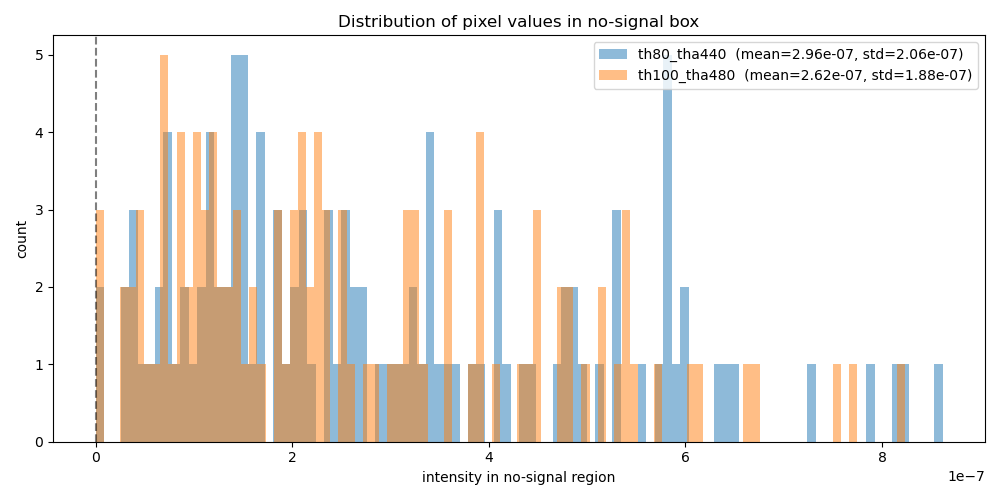


=== Summary: lower mean and std = cleaner noise rejection ===
variant                        mean            std
th80_tha440             +2.9596e-07     2.0596e-07
th100_tha480            +2.6199e-07     1.8829e-07


In [41]:
import numpy as np
import matplotlib.pyplot as plt

# === Region where there should be no real RIXS signal ===
inc_range = (699.5,701.2)
# inc_range = (696.5, 702.5)   # incident energy window (eV)
# emi_range = (710.0, 730.0)   # emission energy window (eV)
emi_range = (690.0, 692.0)   # emission energy window (eV) --- IGNORE ---

# === Extract the region and compute statistics ===
results = {}
for tag, avg in avg_results.items():
    a = avg.average

    # incident energy axis (scanvar) and 2D map
    inc = np.asarray(a['scanvar_off'])
    Z = np.asarray(a['axis_svls_off_mean'])   # shape (n_inc, n_pix)

    # emission axis from calibration
    emi = avg.get_emi()

    # masks for the no-signal box
    inc_mask = (inc >= inc_range[0]) & (inc <= inc_range[1])
    emi_mask = (emi >= emi_range[0]) & (emi <= emi_range[1])

    # extract the box
    sub = Z[np.ix_(inc_mask, emi_mask)]

    # stats
    mean_val = np.nanmean(sub)
    std_val  = np.nanstd(sub)
    n_pix = sub.size

    results[tag] = {
        'Z': Z, 'inc': inc, 'emi': emi,
        'inc_mask': inc_mask, 'emi_mask': emi_mask,
        'sub': sub, 'mean': mean_val, 'std': std_val, 'n': n_pix,
    }

    print(f'{tag}:  mean={mean_val:+.4e}   std={std_val:.4e}   '
          f'({n_pix} pixels, '
          f'{inc_mask.sum()} inc bins × {emi_mask.sum()} emi pixels)')

# === Plot the full RIXS map of each variant, with the no-signal box overlaid ===
n = len(results)
fig, axes = plt.subplots(1, n, figsize=(7*n, 5), sharex=True, sharey=True)
if n == 1:
    axes = [axes]

vmax = np.nanpercentile(np.concatenate([r['Z'].ravel() for r in results.values()]), 99)
for ax, (tag, r) in zip(axes, results.items()):
    im = ax.pcolormesh(r['inc'], r['emi'], r['Z'].T,
                       cmap='terrain_r', vmin=0, vmax=vmax)
    # overlay the no-signal box
    ax.plot([inc_range[0], inc_range[1], inc_range[1], inc_range[0], inc_range[0]],
            [emi_range[0], emi_range[0], emi_range[1], emi_range[1], emi_range[0]],
            'r-', lw=2, label='no-signal region')
    ax.set_xlabel('inc. energy (eV)')
    ax.set_ylabel('emission energy (eV)')
    ax.set_title(f'{tag}\nmean={r["mean"]:.2e}, std={r["std"]:.2e}')
    ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

# === Zoom-in on just the no-signal region for each variant ===
fig, axes = plt.subplots(1, n, figsize=(6*n, 5), sharey=True)
if n == 1:
    axes = [axes]
zoom_vmax = np.nanpercentile(np.concatenate([r['sub'].ravel() for r in results.values()]), 99)
for ax, (tag, r) in zip(axes, results.items()):
    inc_sub = r['inc'][r['inc_mask']]
    emi_sub = r['emi'][r['emi_mask']]
    ax.pcolormesh(inc_sub, emi_sub, r['sub'].T,
                  cmap='terrain_r', vmin=0, vmax=zoom_vmax)
    ax.set_xlabel('inc. energy (eV)')
    ax.set_ylabel('emission energy (eV)')
    ax.set_title(f'{tag} — no-signal region\nmean={r["mean"]:.2e}  std={r["std"]:.2e}')
plt.tight_layout()
plt.show()

# === Histograms of the pixel values in the no-signal region ===
fig, ax = plt.subplots(figsize=(10, 5))
for tag, r in results.items():
    vals = r['sub'].ravel()
    vals = vals[~np.isnan(vals)]
    ax.hist(vals, bins=100, alpha=0.5,
            label=f'{tag}  (mean={r["mean"]:.2e}, std={r["std"]:.2e})')
ax.axvline(0, color='k', ls='--', alpha=0.5)
ax.set_xlabel('intensity in no-signal region')
ax.set_ylabel('count')
# ax.set_yscale('log')
ax.set_title('Distribution of pixel values in no-signal box')
ax.legend()
plt.tight_layout()
plt.show()

# === Summary ===
print('\n=== Summary: lower mean and std = cleaner noise rejection ===')
print(f'{"variant":<20} {"mean":>14} {"std":>14}')
for tag, r in results.items():
    print(f'{tag:<20} {r["mean"]:>+14.4e} {r["std"]:>14.4e}')